In [1]:
import pandas as pd

import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv.zip')

/tmp/ipykernel_787/694676680.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv.zip')


In [4]:
dataset.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [5]:
dataset.shape

(100000, 28)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [7]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [8]:
dataset.describe(exclude=np.number).T

,count,unique,top,freq
ID,100000,100000,0x25fd5,1
Customer_ID,100000,12500,CUS_0x942c,8
Month,100000,8,January,12500
Name,90015,10139,Stevex,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,36585.12,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


In [9]:
cat_col = dataset.select_dtypes(include='object').columns
cat_col

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [10]:
num_col =  dataset.select_dtypes(exclude = 'object').columns
num_col

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

In [11]:
import numpy as np

# List of columns that are currently 'object' type but should be numeric
# Based on `dataset.info()` and `dataset.describe(exclude=np.number).T` outputs
numeric_object_columns = [
    'Age',
    'Annual_Income',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in numeric_object_columns:
    if col in dataset.columns:
        # Replace common non-numeric strings with NaN before conversion
        # Use a more general regex to catch variations of underscores and special characters
        dataset[col] = dataset[col].astype(str).str.replace(r'[^\d.-]+', '', regex=True)
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

print("Data types after converting object columns to numeric:")
dataset.info()

Data types after converting object columns to numeric:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int

In [12]:
q3 = dataset['Num_Credit_Inquiries'].quantile(0.75)
q4 = dataset['Num_Credit_Inquiries'].quantile(1.0) # This is equivalent to .max()

values_between_q3_q4 = dataset[(dataset['Num_Credit_Inquiries'] > q3) & (dataset['Num_Credit_Inquiries'] <= q4)]['Num_Credit_Inquiries']

print(f"Values in 'Num_Credit_Inquiries' between Q3 ({q3}) and Q4 ({q4}):")
display(values_between_q3_q4)

Values in 'Num_Credit_Inquiries' between Q3 (9.0) and Q4 (2597.0):


,Num_Credit_Inquiries
140,10.0
141,10.0
142,10.0
143,10.0
173,1050.0
...,...
99851,12.0
99853,12.0
99854,12.0
99855,12.0


In [13]:
cat_col = dataset.select_dtypes(include='object').columns
cat_col

Index(['ID', 'Customer_ID', 'Month', 'Name', 'SSN', 'Occupation',
       'Type_of_Loan', 'Credit_Mix', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [14]:
num_col =  dataset.select_dtypes(exclude = 'object').columns
num_col

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'],
      dtype='object')

In [15]:
for col in cat_col:
  if dataset[col].isna().sum() > 0 :
    print(col)


Name
Type_of_Loan
Credit_History_Age


In [16]:
dataset=dataset.drop(columns=['Name'])

In [17]:
dataset['Type_of_Loan_missing_flag'] = dataset['Type_of_Loan'].isnull().astype(int)
dataset['Type_of_Loan'] = dataset['Type_of_Loan'].fillna('Missing')
dataset['Type_of_Loan'].isna().sum()

np.int64(0)

In [18]:
dataset['Credit_History_Age'].value_counts()

,count
Credit_History_Age,
15 Years and 11 Months,446
19 Years and 4 Months,445
19 Years and 5 Months,444
17 Years and 11 Months,443
19 Years and 3 Months,441
...,...
0 Years and 3 Months,20
0 Years and 2 Months,15
33 Years and 7 Months,14


In [19]:
import re

def convert_to_months(x):
  if pd.isna(x):
    return np.nan


  years = int(re.search(r'(\d+)\s*Years',x).group(1)) if 'Years' in x else 0
  months = int(re.search(r'(\d+)\s*Months',x).group(1)) if 'Months' in x else 0

  return years*12 + months



In [20]:
dataset['Credit_history_months'] = dataset['Credit_History_Age'].apply(convert_to_months)

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         100000 non-null  object 
 1   Customer_ID                100000 non-null  object 
 2   Month                      100000 non-null  object 
 3   Age                        100000 non-null  int64  
 4   SSN                        100000 non-null  object 
 5   Occupation                 100000 non-null  object 
 6   Annual_Income              100000 non-null  float64
 7   Monthly_Inhand_Salary      84998 non-null   float64
 8   Num_Bank_Accounts          100000 non-null  int64  
 9   Num_Credit_Card            100000 non-null  int64  
 10  Interest_Rate              100000 non-null  int64  
 11  Num_of_Loan                100000 non-null  int64  
 12  Type_of_Loan               100000 non-null  object 
 13  Delay_from_due_date        100

In [22]:
dataset['Credit_history_months'].isna().sum()

np.int64(9030)

In [23]:
dataset = dataset.drop(columns = ['Credit_History_Age'])

In [24]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         100000 non-null  object 
 1   Customer_ID                100000 non-null  object 
 2   Month                      100000 non-null  object 
 3   Age                        100000 non-null  int64  
 4   SSN                        100000 non-null  object 
 5   Occupation                 100000 non-null  object 
 6   Annual_Income              100000 non-null  float64
 7   Monthly_Inhand_Salary      84998 non-null   float64
 8   Num_Bank_Accounts          100000 non-null  int64  
 9   Num_Credit_Card            100000 non-null  int64  
 10  Interest_Rate              100000 non-null  int64  
 11  Num_of_Loan                100000 non-null  int64  
 12  Type_of_Loan               100000 non-null  object 
 13  Delay_from_due_date        100

In [25]:
missing_percent = dataset['Credit_history_months'].isnull().mean()*100
print(f"Missing Percentage: {missing_percent:.2f}%")

Missing Percentage: 9.03%


missing_percent = dataset_train.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

In [26]:
dataset['Credit_History_missing_flag'] = dataset['Credit_history_months'].isnull().astype(int)

In [27]:
dataset.groupby(
    dataset['Credit_History_missing_flag']
)['Credit_Score'].value_counts(normalize=True)

Credit_History_missing_flag  Credit_Score
0                            Standard        0.531494
                             Poor            0.290162
                             Good            0.178345
1                            Standard        0.534219
                             Poor            0.288151
                             Good            0.177630
Name: proportion, dtype: float64

In [28]:
dataset = dataset.drop(columns=['Credit_History_missing_flag'])

In [29]:
dataset['Credit_history_months'].fillna(dataset['Credit_history_months'].median(),inplace= True)

/tmp/ipykernel_787/249703920.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Credit_history_months'].fillna(dataset['Credit_history_months'].median(),inplace= True)


In [30]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         100000 non-null  object 
 1   Customer_ID                100000 non-null  object 
 2   Month                      100000 non-null  object 
 3   Age                        100000 non-null  int64  
 4   SSN                        100000 non-null  object 
 5   Occupation                 100000 non-null  object 
 6   Annual_Income              100000 non-null  float64
 7   Monthly_Inhand_Salary      84998 non-null   float64
 8   Num_Bank_Accounts          100000 non-null  int64  
 9   Num_Credit_Card            100000 non-null  int64  
 10  Interest_Rate              100000 non-null  int64  
 11  Num_of_Loan                100000 non-null  int64  
 12  Type_of_Loan               100000 non-null  object 
 13  Delay_from_due_date        100

In [31]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


In [32]:
bad_age_count = dataset[(dataset['Age']<18)|(dataset['Age']>100)].shape[0]
bad_age_count

8482

In [33]:
total_rows = dataset.shape[0]
total_rows

100000

In [34]:
100*bad_age_count/total_rows

8.482

In [35]:
dataset.loc[(dataset['Age']<18)|(dataset['Age']>100),'Age'] = np.nan

In [36]:
dataset['Age'].isna().mean()*100

np.float64(8.482000000000001)

In [37]:
dataset['Age'].fillna(dataset['Age'].median(),inplace=True)

/tmp/ipykernel_787/1263768913.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Age'].fillna(dataset['Age'].median(),inplace=True)


In [38]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,3.439336e+01,9.685699e+00,1.800000e+01,27.000000,34.000000,41.000000,1.000000e+02
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


In [39]:
bad_accounts = dataset[(dataset['Num_Bank_Accounts']<0)].shape[0]
print('Negative Values:', bad_accounts)
print('Percentage:',(bad_accounts/dataset.shape[0])*100)

Negative Values: 21
Percentage: 0.021


In [40]:
dataset = dataset[dataset['Num_Bank_Accounts']>=0]

In [41]:
dataset['Num_Bank_Accounts'].describe()

,Num_Bank_Accounts
count,99979.000000
mean,17.095080
std,117.416871
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,1798.000000


In [42]:
dataset['Num_Bank_Accounts'].quantile([0.95,0.99])

,Num_Bank_Accounts
0.95,10.00
0.99,445.22


In [43]:

(dataset['Num_Bank_Accounts']>20).mean()*100

np.float64(1.3142759979595715)

In [44]:
dataset['Num_Bank_Accounts'] = dataset['Num_Bank_Accounts'].clip(upper = 20)

In [45]:
dataset['Num_Bank_Accounts'].describe()

,Num_Bank_Accounts
count,99979.000000
mean,5.561398
std,3.067642
min,0.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,20.000000


In [46]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,99979.0,3.439135e+01,9.685152e+00,1.800000e+01,27.000000,34.000000,41.000000,1.000000e+02
Annual_Income,99979.0,1.762146e+05,1.428080e+06,7.005930e+03,19455.490000,37578.610000,72783.060000,2.419806e+07
Monthly_Inhand_Salary,84979.0,4.193601e+03,3.183276e+03,3.036454e+02,1625.558333,3093.153333,5956.010000,1.520463e+04
Num_Bank_Accounts,99979.0,5.561398e+00,3.067642e+00,0.000000e+00,3.000000,6.000000,7.000000,2.000000e+01
Num_Credit_Card,99979.0,2.247648e+01,1.290699e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,99979.0,7.248027e+01,4.664706e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,99979.0,3.011322e+00,6.265360e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,99979.0,2.107031e+01,1.486072e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92977.0,3.092953e+01,2.260570e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97888.0,1.038969e+01,6.789925e+00,-6.490000e+00,5.330000,9.410000,14.870000,3.697000e+01


In [47]:

dataset['Num_Credit_Card'].describe()

,Num_Credit_Card
count,99979.000000
mean,22.476480
std,129.069941
min,0.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,1499.000000


In [48]:
dataset['Num_Credit_Card'].quantile([0.95,0.99])

,Num_Credit_Card
0.95,10.0
0.99,849.0


In [49]:
(dataset['Num_Credit_Card']>15).mean()*100

np.float64(2.267476169995699)

In [50]:
dataset['Num_Credit_Card'] = dataset['Num_Credit_Card'].clip(upper=15)

In [51]:
dataset['Num_Credit_Card'].describe()

,Num_Credit_Card
count,99979.000000
mean,5.748347
std,2.483417
min,0.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,15.000000


In [52]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,99979.0,3.439135e+01,9.685152e+00,1.800000e+01,27.000000,34.000000,41.000000,1.000000e+02
Annual_Income,99979.0,1.762146e+05,1.428080e+06,7.005930e+03,19455.490000,37578.610000,72783.060000,2.419806e+07
Monthly_Inhand_Salary,84979.0,4.193601e+03,3.183276e+03,3.036454e+02,1625.558333,3093.153333,5956.010000,1.520463e+04
Num_Bank_Accounts,99979.0,5.561398e+00,3.067642e+00,0.000000e+00,3.000000,6.000000,7.000000,2.000000e+01
Num_Credit_Card,99979.0,5.748347e+00,2.483417e+00,0.000000e+00,4.000000,5.000000,7.000000,1.500000e+01
Interest_Rate,99979.0,7.248027e+01,4.664706e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,99979.0,3.011322e+00,6.265360e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,99979.0,2.107031e+01,1.486072e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92977.0,3.092953e+01,2.260570e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97888.0,1.038969e+01,6.789925e+00,-6.490000e+00,5.330000,9.410000,14.870000,3.697000e+01


In [53]:
negative_loans = dataset[(dataset['Num_of_Loan']<0)].shape[0]
print(negative_loans)
print((negative_loans/dataset.shape[0])*100)

3875
3.875813920923394


In [54]:
dataset['Num_of_Loan'].describe()

,Num_of_Loan
count,99979.000000
mean,3.011322
std,62.653605
min,-100.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,1496.000000


In [55]:
dataset['Num_of_Loan'].quantile([0.95,0.99])

,Num_of_Loan
0.95,8.0
0.99,9.0


In [56]:
((dataset['Num_of_Loan']>10)).mean()*100

np.float64(0.4720991408195721)

In [57]:
count_gt_10 = dataset[(dataset['Num_of_Loan']>10) & (dataset['Num_of_Loan']<100)].shape[0]
print(count_gt_10)
print(dataset[(dataset['Num_of_Loan']>10)].shape[0])

34
472


In [58]:
dataset.loc[dataset['Num_of_Loan']< 0,'Num_of_Loan'] = np.nan

In [59]:
dataset['Num_of_Loan'].median()

3.0

In [60]:
dataset['Num_of_Loan'].fillna(dataset['Num_of_Loan'].median(),inplace = True)

/tmp/ipykernel_787/704572107.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Num_of_Loan'].fillna(dataset['Num_of_Loan'].median(),inplace = True)


In [61]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,99979.0,3.439135e+01,9.685152e+00,1.800000e+01,27.000000,34.000000,41.000000,1.000000e+02
Annual_Income,99979.0,1.762146e+05,1.428080e+06,7.005930e+03,19455.490000,37578.610000,72783.060000,2.419806e+07
Monthly_Inhand_Salary,84979.0,4.193601e+03,3.183276e+03,3.036454e+02,1625.558333,3093.153333,5956.010000,1.520463e+04
Num_Bank_Accounts,99979.0,5.561398e+00,3.067642e+00,0.000000e+00,3.000000,6.000000,7.000000,2.000000e+01
Num_Credit_Card,99979.0,5.748347e+00,2.483417e+00,0.000000e+00,4.000000,5.000000,7.000000,1.500000e+01
Interest_Rate,99979.0,7.248027e+01,4.664706e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,99979.0,7.003411e+00,5.914607e+01,0.000000e+00,2.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,99979.0,2.107031e+01,1.486072e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92977.0,3.092953e+01,2.260570e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97888.0,1.038969e+01,6.789925e+00,-6.490000e+00,5.330000,9.410000,14.870000,3.697000e+01


In [62]:
100*(dataset[dataset['Delay_from_due_date']<0].shape[0])/dataset.shape[0]

0.5911241360685744

In [63]:
dataset['Delay_from_due_date'].quantile([0.95,0.99])

,Delay_from_due_date
0.95,54.0
0.99,61.0


In [64]:
neg_delay = dataset[
    dataset['Delay_from_due_date'] < 0
].shape[0]

print("Negative %:",
      (neg_delay / dataset.shape[0]) * 100)

Negative %: 0.5911241360685744


In [65]:
dataset.loc[dataset['Delay_from_due_date']<0,'Delay_from_due_date'] = 0

In [66]:
dataset['Delay_from_due_date'].describe()

,Delay_from_due_date
count,99979.000000
mean,21.083448
std,14.840813
min,0.000000
25%,10.000000
50%,18.000000
75%,28.000000
max,67.000000


In [67]:
dataset['Num_of_Delayed_Payment'].describe()

,Num_of_Delayed_Payment
count,92977.000000
mean,30.929531
std,226.057039
min,-3.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,4397.000000


In [68]:
dataset['Num_of_Delayed_Payment'].quantile([0.95,0.99])

,Num_of_Delayed_Payment
0.95,24.0
0.99,27.0


In [69]:
(dataset[dataset['Num_of_Delayed_Payment']>100].shape[0])/dataset.shape[0]*100

0.7241520719351063

In [70]:
(dataset['Num_of_Delayed_Payment']>100).mean()*100

np.float64(0.7241520719351063)

In [71]:
dataset['Num_of_Delayed_Payment'] = dataset['Num_of_Delayed_Payment'].clip(upper=30)

In [72]:
dataset['Num_of_Delayed_Payment'].describe()

,Num_of_Delayed_Payment
count,92977.000000
mean,13.448702
std,6.457374
min,-3.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,30.000000


In [73]:
dataset['Annual_Income'].describe()

,Annual_Income
count,9.997900e+04
mean,1.762146e+05
std,1.428080e+06
min,7.005930e+03
25%,1.945549e+04
50%,3.757861e+04
75%,7.278306e+04
max,2.419806e+07


<Axes: >

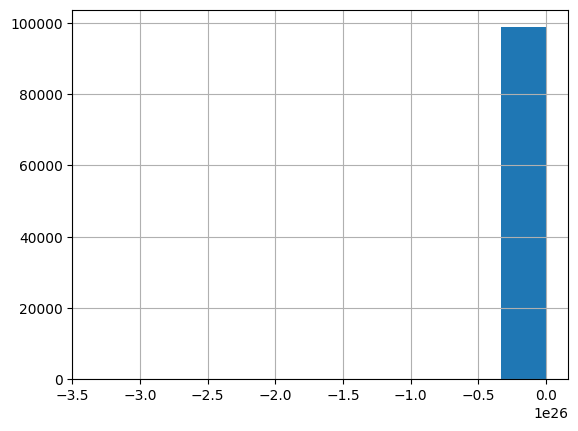

In [74]:
dataset['Monthly_Balance'].hist()

In [75]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,99979.0,3.439135e+01,9.685152e+00,1.800000e+01,27.000000,34.000000,41.000000,1.000000e+02
Annual_Income,99979.0,1.762146e+05,1.428080e+06,7.005930e+03,19455.490000,37578.610000,72783.060000,2.419806e+07
Monthly_Inhand_Salary,84979.0,4.193601e+03,3.183276e+03,3.036454e+02,1625.558333,3093.153333,5956.010000,1.520463e+04
Num_Bank_Accounts,99979.0,5.561398e+00,3.067642e+00,0.000000e+00,3.000000,6.000000,7.000000,2.000000e+01
Num_Credit_Card,99979.0,5.748347e+00,2.483417e+00,0.000000e+00,4.000000,5.000000,7.000000,1.500000e+01
Interest_Rate,99979.0,7.248027e+01,4.664706e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,99979.0,7.003411e+00,5.914607e+01,0.000000e+00,2.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,99979.0,2.108345e+01,1.484081e+01,0.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92977.0,1.344870e+01,6.457374e+00,-3.000000e+00,9.000000,14.000000,18.000000,3.000000e+01
Changed_Credit_Limit,97888.0,1.038969e+01,6.789925e+00,-6.490000e+00,5.330000,9.410000,14.870000,3.697000e+01


In [76]:
dataset.shape

(99979, 28)

In [77]:
dataset['Annual_Income'].describe()

,Annual_Income
count,9.997900e+04
mean,1.762146e+05
std,1.428080e+06
min,7.005930e+03
25%,1.945549e+04
50%,3.757861e+04
75%,7.278306e+04
max,2.419806e+07


In [78]:
#checking negative value - no negatiive value
print((dataset['Annual_Income']<=0).mean())

0.0


In [79]:
#missing values

dataset['Annual_Income'].isna().sum()

np.int64(0)

In [80]:
# checking outliers

dataset['Annual_Income'].quantile([0.90,0.95,0.99,1])

,Annual_Income
0.90,113040.28
0.95,134533.32
0.99,179987.28
1.00,24198062.00


this means 1% has highly skeweed data
normal high income = 99 percentile
it can be data error

In [81]:
upper_limit = dataset['Annual_Income'].quantile(0.99)

dataset['Annual_Income']  = dataset['Annual_Income'].clip(upper = upper_limit)

In [82]:
# log transformation

import numpy as np
dataset['Annual_Income_log'] = np.log1p(dataset['Annual_Income'])

In [83]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,99979.0,3.439135e+01,9.685152e+00,1.800000e+01,27.000000,34.000000,41.000000,100.000000
Annual_Income,99979.0,5.178348e+04,4.021616e+04,7.005930e+03,19455.490000,37578.610000,72783.060000,179987.280000
Monthly_Inhand_Salary,84979.0,4.193601e+03,3.183276e+03,3.036454e+02,1625.558333,3093.153333,5956.010000,15204.633333
Num_Bank_Accounts,99979.0,5.561398e+00,3.067642e+00,0.000000e+00,3.000000,6.000000,7.000000,20.000000
Num_Credit_Card,99979.0,5.748347e+00,2.483417e+00,0.000000e+00,4.000000,5.000000,7.000000,15.000000
Interest_Rate,99979.0,7.248027e+01,4.664706e+02,1.000000e+00,8.000000,13.000000,20.000000,5797.000000
Num_of_Loan,99979.0,7.003411e+00,5.914607e+01,0.000000e+00,2.000000,3.000000,5.000000,1496.000000
Delay_from_due_date,99979.0,2.108345e+01,1.484081e+01,0.000000e+00,10.000000,18.000000,28.000000,67.000000
Num_of_Delayed_Payment,92977.0,1.344870e+01,6.457374e+00,-3.000000e+00,9.000000,14.000000,18.000000,30.000000
Changed_Credit_Limit,97888.0,1.038969e+01,6.789925e+00,-6.490000e+00,5.330000,9.410000,14.870000,36.970000


In [84]:
dataset['Monthly_Balance'].describe()

,Monthly_Balance
count,9.877900e+04
mean,-3.037083e+22
std,3.181633e+24
min,-3.333333e+26
25%,2.700853e+02
50%,3.366966e+02
75%,4.701282e+02
max,1.602041e+03


In [85]:
dataset.nlargest(10,'Monthly_Balance')['Monthly_Balance']

,Monthly_Balance
9376,1602.040519
7475,1576.288935
33072,1567.208309
17029,1566.613165
15878,1564.134826
34161,1558.421841
33076,1555.201051
68000,1552.946094
96432,1546.319640
62954,1542.274695


In [86]:
dataset.nsmallest(10,'Monthly_Balance')['Monthly_Balance']

,Monthly_Balance
5545,-3.333333e+26
26177,-3.333333e+26
29158,-3.333333e+26
35570,-3.333333e+26
38622,-3.333333e+26
60009,-3.333333e+26
75251,-3.333333e+26
82918,-3.333333e+26
83255,-3.333333e+26
71453,7.759665e-03


In [87]:
(dataset['Monthly_Balance'].abs() > 10000).mean() * 100

np.float64(0.009001890396983367)

In [88]:
#since only .009% rows have absurd balance -  drop those rows

dataset = dataset[dataset['Monthly_Balance'].abs() <= 10000]

In [89]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,98770.0,34.403695,9.687134,18.000000,27.000000,34.000000,41.000000,100.000000
Annual_Income,98770.0,51289.436906,40013.247420,7005.930000,19328.710000,36945.280000,72050.920000,179987.280000
Monthly_Inhand_Salary,83942.0,4151.751183,3164.037431,303.645417,1618.361667,3057.391667,5906.740000,15204.633333
Num_Bank_Accounts,98770.0,5.556151,3.066062,0.000000,3.000000,6.000000,7.000000,20.000000
Num_Credit_Card,98770.0,5.745277,2.482680,0.000000,4.000000,5.000000,7.000000,15.000000
Interest_Rate,98770.0,72.519864,466.697174,1.000000,8.000000,13.000000,20.000000,5797.000000
Num_of_Loan,98770.0,7.004860,59.388081,0.000000,2.000000,3.000000,5.000000,1496.000000
Delay_from_due_date,98770.0,21.052698,14.822714,0.000000,10.000000,18.000000,28.000000,67.000000
Num_of_Delayed_Payment,91863.0,13.437554,6.452368,-3.000000,9.000000,14.000000,18.000000,30.000000
Changed_Credit_Limit,96697.0,10.380487,6.779550,-6.490000,5.330000,9.400000,14.830000,36.970000


In [90]:
dataset['Credit_Utilization_Ratio'].describe()

,Credit_Utilization_Ratio
count,98770.000000
mean,32.313884
std,5.111097
min,20.881250
25%,28.079444
50%,32.335367
75%,36.521620
max,50.000000


In [91]:
(dataset['Credit_Utilization_Ratio'] < 0).mean()*100

np.float64(0.0)

In [92]:
(dataset['Credit_Utilization_Ratio'] > 100).mean()*100

np.float64(0.0)

In [93]:
dataset['Credit_Utilization_Ratio'].isna().sum()

np.int64(0)

<Axes: >

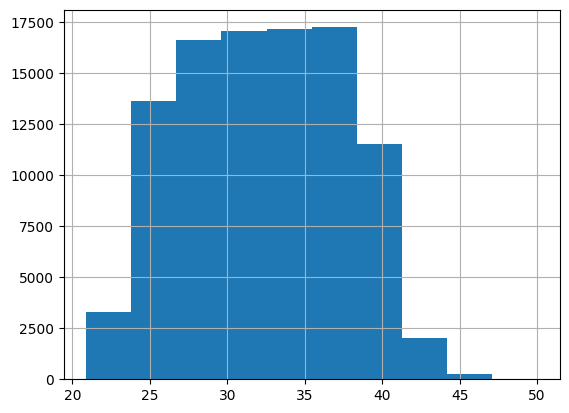

In [94]:
dataset['Credit_Utilization_Ratio'].hist()

In [95]:
dataset.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,14828
Num_Bank_Accounts,0
Num_Credit_Card,0


In [96]:
num_col

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'],
      dtype='object')

In [97]:

dataset['Monthly_Inhand_Salary'].describe()

,Monthly_Inhand_Salary
count,83942.000000
mean,4151.751183
std,3164.037431
min,303.645417
25%,1618.361667
50%,3057.391667
75%,5906.740000
max,15204.633333


In [98]:
dataset['Monthly_Inhand_Salary'].isna().mean()*100

np.float64(15.012655664675508)

In [99]:
dataset[['Annual_Income','Monthly_Inhand_Salary']].corr()

,Annual_Income,Monthly_Inhand_Salary
Annual_Income,1.000000,0.940119
Monthly_Inhand_Salary,0.940119,1.000000


In [100]:
dataset[dataset['Monthly_Inhand_Salary'].isna()][['Annual_Income','Monthly_Inhand_Salary']]

,Annual_Income,Monthly_Inhand_Salary
1,19114.12,NaN
2,19114.12,NaN
3,19114.12,NaN
5,19114.12,NaN
11,34847.84,NaN
...,...,...
99944,59146.36,NaN
99955,38321.39,NaN
99963,42903.79,NaN
99975,16680.35,NaN


In [101]:
dataset.loc[dataset['Monthly_Inhand_Salary'].isnull(),'Monthly_Inhand_Salary'] = dataset['Annual_Income']/12

In [102]:
dataset['Monthly_Inhand_Salary'].isna().sum()

np.int64(0)

In [103]:
dataset['Num_of_Delayed_Payment'].isna().mean()*100

np.float64(6.993014073099118)

<Axes: >

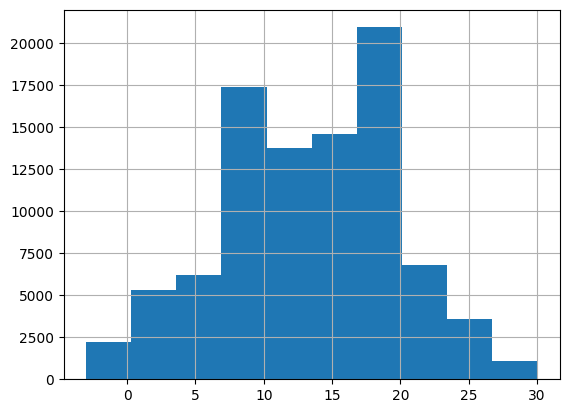

In [104]:
dataset['Num_of_Delayed_Payment'].hist()

In [105]:
dataset['Num_of_Delayed_Payment'].describe()

,Num_of_Delayed_Payment
count,91863.000000
mean,13.437554
std,6.452368
min,-3.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,30.000000


In [106]:
dataset['Num_of_Delayed_Payment'].quantile([0.01,0.95,0.99])

,Num_of_Delayed_Payment
0.01,0.0
0.95,24.0
0.99,27.0


In [107]:
dataset[dataset['Num_of_Delayed_Payment']<0]['Num_of_Delayed_Payment']

,Num_of_Delayed_Payment
10,-1.0
698,-1.0
1253,-3.0
1561,-2.0
2167,-1.0
...,...
99269,-2.0
99512,-2.0
99515,-2.0
99586,-2.0


In [108]:
(dataset['Num_of_Delayed_Payment']<=-3).mean() * 100

np.float64(0.09112078566366306)

In [109]:
from scipy import stats
stats.percentileofscore(dataset['Num_of_Delayed_Payment'],-3)

np.float64(nan)

In [110]:
dataset['Num_of_Delayed_Payment'].skew()

np.float64(-0.1199256653373266)

In [111]:
dataset['Num_of_Delayed_Payment'].fillna(dataset['Num_of_Delayed_Payment'].median(),inplace = True)

/tmp/ipykernel_787/3062471569.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Num_of_Delayed_Payment'].fillna(dataset['Num_of_Delayed_Payment'].median(),inplace = True)


In [112]:
dataset['Num_of_Delayed_Payment'].isna().sum()

np.int64(0)

In [113]:
(dataset['Num_of_Delayed_Payment']<0).mean()*100

np.float64(0.6449326718639262)

In [114]:
dataset.loc[dataset['Num_of_Delayed_Payment']<0,'Num_of_Delayed_Payment']=np.nan

In [115]:
dataset['Num_of_Delayed_Payment'].isna().mean()*100

np.float64(0.6449326718639262)

In [116]:
dataset['Num_of_Delayed_Payment'].fillna(dataset['Num_of_Delayed_Payment'].median(),inplace=True)

/tmp/ipykernel_787/4229150993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Num_of_Delayed_Payment'].fillna(dataset['Num_of_Delayed_Payment'].median(),inplace=True)


In [117]:
dataset['Num_of_Delayed_Payment'].isna().sum()

np.int64(0)

In [118]:
dataset['Changed_Credit_Limit'].describe()

,Changed_Credit_Limit
count,96697.000000
mean,10.380487
std,6.779550
min,-6.490000
25%,5.330000
50%,9.400000
75%,14.830000
max,36.970000


In [119]:
dataset['Changed_Credit_Limit'].isna().mean()*100

np.float64(2.0988154297863724)

In [120]:
dataset['Changed_Credit_Limit'].isna().mean()*100

np.float64(2.0988154297863724)

In [121]:
dataset['Changed_Credit_Limit'].skew()

np.float64(0.6406899708845395)

In [122]:
dataset['Changed_Credit_Limit'].fillna(dataset['Changed_Credit_Limit'].mean(),inplace = True)

/tmp/ipykernel_787/2486445875.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Changed_Credit_Limit'].fillna(dataset['Changed_Credit_Limit'].mean(),inplace = True)


In [123]:
dataset.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0


In [124]:
dataset['Num_Credit_Inquiries'].describe()

,Num_Credit_Inquiries
count,96833.000000
mean,27.740068
std,193.131724
min,0.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,2597.000000


In [125]:
dataset['Num_Credit_Inquiries'].isna().sum()

np.int64(1937)

In [126]:
dataset['Num_Credit_Inquiries'].skew()

np.float64(9.787205213931147)

In [127]:
dataset['Num_Credit_Inquiries'].quantile([0.95,0.97,.99])

,Num_Credit_Inquiries
0.95,13.00
0.97,15.00
0.99,1109.44


In [128]:
(dataset['Num_Credit_Inquiries']>20).mean()*100

np.float64(1.6482737673382608)

In [129]:
dataset['Num_Credit_Inquiries'] = dataset['Num_Credit_Inquiries'].clip(upper=20)

In [130]:
dataset['Num_Credit_Inquiries'].isna().mean()

np.float64(0.019611217981168372)

In [131]:
dataset['Num_Credit_Inquiries'].median()

6.0

In [132]:
dataset['Num_Credit_Inquiries'].fillna(dataset['Num_Credit_Inquiries'].median(),inplace=True)

/tmp/ipykernel_787/2667992507.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Num_Credit_Inquiries'].fillna(dataset['Num_Credit_Inquiries'].median(),inplace=True)


In [133]:
dataset['Num_Credit_Inquiries'].describe()

,Num_Credit_Inquiries
count,98770.000000
mean,6.011866
std,4.201864
min,0.000000
25%,3.000000
50%,6.000000
75%,9.000000
max,20.000000


In [134]:
dataset['Amount_invested_monthly'].isna().sum()

np.int64(4420)

In [135]:
dataset['Amount_invested_monthly'].describe()

,Amount_invested_monthly
count,94350.000000
mean,627.782236
std,2039.103945
min,0.000000
25%,73.918441
50%,133.917048
75%,257.549996
max,10000.000000


In [136]:

dataset['Amount_invested_monthly'].quantile([0.95,0.97,0.99])

,Amount_invested_monthly
0.95,1032.900311
0.97,10000.000000
0.99,10000.000000


In [137]:
(dataset['Amount_invested_monthly']>2000).mean()*100

np.float64(4.285714285714286)

In [138]:
dataset['Amount_invested_monthly'] = dataset['Amount_invested_monthly'].clip(upper=1500)

In [139]:
dataset.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Type_of_Loan_missing_flag,Credit_history_months,Annual_Income_log
count,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,94350.000000,98770.000000,98770.000000,98770.000000,98770.000000
mean,34.403695,51289.436906,4173.496444,5.556151,5.745277,72.519864,7.004860,21.052698,13.577797,10.380487,6.011866,1422.358682,32.313884,1404.825378,246.425648,402.502182,0.115237,221.284914,10.542062
std,9.687134,40013.247420,3192.535127,3.066062,2.482680,466.697174,59.388081,14.822714,6.103715,6.708027,4.201864,1151.785612,5.111097,8318.022820,325.161639,213.881652,0.319310,95.070115,0.800467
min,18.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-6.490000,0.000000,0.230000,20.881250,0.000000,0.000000,0.007760,0.000000,1.000000,8.854655
25%,27.000000,19328.710000,1618.361667,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.420000,3.000000,565.340000,28.079444,29.991413,73.918441,270.096051,0.000000,154.000000,9.869399
50%,34.000000,36945.280000,3062.030833,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.550000,6.000000,1163.930000,32.335367,68.132721,133.917048,336.710154,0.000000,219.000000,10.517220
75%,41.000000,72050.920000,5913.403333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.637500,9.000000,1938.260000,36.521620,155.879984,257.549996,470.173589,0.000000,292.000000,11.185142
max,100.000000,179987.280000,15204.633333,20.000000,15.000000,5797.000000,1496.000000,67.000000,30.000000,36.970000,20.000000,4998.070000,50.000000,82331.000000,1500.000000,1602.040519,1.000000,404.000000,12.100647


In [140]:
dataset['Amount_invested_monthly'].fillna(dataset['Amount_invested_monthly'].median(),inplace=True)

/tmp/ipykernel_787/3166335353.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Amount_invested_monthly'].fillna(dataset['Amount_invested_monthly'].median(),inplace=True)


In [141]:
dataset.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0


In [142]:
cap_value = dataset['Interest_Rate'].quantile(0.97)
cap_value
dataset['Interest_Rate'] = dataset['Interest_Rate'].clip(upper=cap_value)
dataset['Interest_Rate'].describe()

,Interest_Rate
count,98770.000000
mean,14.912747
std,9.073773
min,1.000000
25%,8.000000
50%,13.000000
75%,20.000000
max,34.000000


In [143]:
dataset.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Type_of_Loan_missing_flag,Credit_history_months,Annual_Income_log
count,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000
mean,34.403695,51289.436906,4173.496444,5.556151,5.745277,14.912747,7.004860,21.052698,13.577797,10.380487,6.011866,1422.358682,32.313884,1404.825378,241.390840,402.502182,0.115237,221.284914,10.542062
std,9.687134,40013.247420,3192.535127,3.066062,2.482680,9.073773,59.388081,14.822714,6.103715,6.708027,4.201864,1151.785612,5.111097,8318.022820,318.652933,213.881652,0.319310,95.070115,0.800467
min,18.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-6.490000,0.000000,0.230000,20.881250,0.000000,0.000000,0.007760,0.000000,1.000000,8.854655
25%,27.000000,19328.710000,1618.361667,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.420000,3.000000,565.340000,28.079444,29.991413,76.365701,270.096051,0.000000,154.000000,9.869399
50%,34.000000,36945.280000,3062.030833,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.550000,6.000000,1163.930000,32.335367,68.132721,133.917048,336.710154,0.000000,219.000000,10.517220
75%,41.000000,72050.920000,5913.403333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.637500,9.000000,1938.260000,36.521620,155.879984,247.435591,470.173589,0.000000,292.000000,11.185142
max,100.000000,179987.280000,15204.633333,20.000000,15.000000,34.000000,1496.000000,67.000000,30.000000,36.970000,20.000000,4998.070000,50.000000,82331.000000,1500.000000,1602.040519,1.000000,404.000000,12.100647


In [144]:
cap_num_of_loan = dataset['Num_of_Loan'].quantile(0.99)
cap_num_of_loan

np.float64(9.0)

In [145]:
dataset['Num_of_Loan'].describe()

,Num_of_Loan
count,98770.000000
mean,7.004860
std,59.388081
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,1496.000000


In [146]:
dataset['Num_of_Loan'] = dataset['Num_of_Loan'].clip(upper = cap_num_of_loan)

In [147]:
dataset['Num_of_Loan'].describe()

,Num_of_Loan
count,98770.000000
mean,3.519510
std,2.418669
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,9.000000


## **FEAUTURE ENGINEERING**

Debt to Income Ratio:

In [148]:
dataset.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour',
       'Monthly_Balance', 'Credit_Score', 'Type_of_Loan_missing_flag',
       'Credit_history_months', 'Annual_Income_log'],
      dtype='object')

In [149]:
dataset['Outstanding_Debt'].describe()

,Outstanding_Debt
count,98770.000000
mean,1422.358682
std,1151.785612
min,0.230000
25%,565.340000
50%,1163.930000
75%,1938.260000
max,4998.070000


In [150]:
dataset['DTI_Ratio'] = dataset['Total_EMI_per_month']/(dataset['Monthly_Inhand_Salary']+1)

dataset['Loans_per_year'] = dataset['Num_of_Loan']/(dataset['Credit_history_months']/12)

dataset['Card_to_account_ratio'] = dataset['Num_Credit_Card']/(dataset['Num_Bank_Accounts']+1)

dataset['Payment_Risk_Score'] = dataset['Num_of_Delayed_Payment']*dataset['Delay_from_due_date']

dataset['Invested_Income_Ratio'] = dataset['Amount_invested_monthly']/(dataset['Monthly_Inhand_Salary']+1)

dataset['Net_Cash_Flow'] = dataset['Monthly_Balance'] - dataset['Total_EMI_per_month']

dataset['Utilization_per_loan'] = dataset['Credit_Utilization_Ratio']/(dataset['Num_of_Loan']+1)

dataset['Inquiry_per_loan'] = dataset['Num_Credit_Inquiries']/(dataset['Num_of_Loan']+1)

dataset['Credit_experience_ratio'] = dataset['Credit_history_months']/dataset['Age']

dataset['Debt_to_income'] = dataset['Outstanding_Debt']/(dataset['Annual_Income']+1)

In [151]:
dataset['DTI_Ratio'].quantile([0.95,0.97,0.99])

,DTI_Ratio
0.95,0.101728
0.97,1.275271
0.99,18.776015


In [152]:
cap = dataset['DTI_Ratio'].quantile(0.97)
dataset['DTI_Ratio'] = dataset['DTI_Ratio'].clip(upper=cap)
dataset['DTI_Ratio'].describe()

,DTI_Ratio
count,98770.000000
mean,0.067748
std,0.216241
min,0.000000
25%,0.012449
50%,0.025017
75%,0.042268
max,1.275271


In [153]:
print(dataset['Net_Cash_Flow'].quantile([0.95,0.97,0.99]))



0.95     748.988185
0.97     858.038890
0.99    1064.775131
Name: Net_Cash_Flow, dtype: float64


In [154]:
cap = dataset['Net_Cash_Flow'].quantile(0.97)
dataset['Net_Cash_Flow'] = dataset['Net_Cash_Flow'].clip(upper=cap)
dataset['Net_Cash_Flow'].describe()

,Net_Cash_Flow
count,98770.000000
mean,-1007.489339
std,8319.013529
min,-82046.231590
25%,172.211420
50%,264.532884
75%,375.478701
max,858.038890


In [155]:
print(dataset['Loans_per_year'].quantile([0.95,0.97,0.99]))
dataset['Loans_per_year'].describe()

0.95    1.183099
0.97    1.866667
0.99    4.666667
Name: Loans_per_year, dtype: float64


,Loans_per_year
count,98770.000000
mean,0.410948
std,1.278355
min,0.000000
25%,0.074361
50%,0.163265
75%,0.390244
max,108.000000


In [156]:
cap = dataset['Loans_per_year'].quantile(0.97)
dataset['Loans_per_year'] = dataset['Loans_per_year'].clip(upper=cap)
dataset['Loans_per_year'].describe()

,Loans_per_year
count,98770.000000
mean,0.314338
std,0.402976
min,0.000000
25%,0.074361
50%,0.163265
75%,0.390244
max,1.866667


In [157]:
dataset.select_dtypes(include='object').columns

Index(['ID', 'Customer_ID', 'Month', 'SSN', 'Occupation', 'Type_of_Loan',
       'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour',
       'Credit_Score'],
      dtype='object')

In [158]:
y = dataset['Credit_Score']

In [159]:
dataset['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,36116
Good,24056
_,19954
Bad,18644


In [160]:
import pandas as pd

pd.crosstab(dataset['Credit_Mix'],dataset['Credit_Score'], normalize = 'index')

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,0.015179,0.601588,0.383233
Good,0.487488,0.158962,0.353550
Standard,0.055100,0.216220,0.728680
_,0.178962,0.290368,0.530671


In [161]:
dataset['Credit_Mix'] = dataset['Credit_Mix'].replace('_','Unknown')

In [162]:
dataset['Credit_Mix'].value_counts()

,count
Credit_Mix,
Standard,36116
Good,24056
Unknown,19954
Bad,18644


In [163]:
credit_mix_map = {'Bad':0,'Unknown':-1,'Good':2,'Standard':1}
dataset['Credit_Mix_Encoded'] = dataset['Credit_Mix'].map(credit_mix_map)

In [164]:
dataset.select_dtypes(include='object').columns

Index(['ID', 'Customer_ID', 'Month', 'SSN', 'Occupation', 'Type_of_Loan',
       'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour',
       'Credit_Score'],
      dtype='object')

In [165]:
dataset['Payment_of_Min_Amount'].value_counts()

,count
Payment_of_Min_Amount,
Yes,51615
No,35302
NM,11853


In [166]:
payment_map = {'No':0, 'Yes':2, 'NM': 1}
dataset['Min_Payment_Encoded'] = dataset['Payment_of_Min_Amount'].map(payment_map)

In [167]:
dataset.loc[dataset['Payment_Behaviour']=='!@9#%8','Payment_Behaviour'] = np.nan

In [168]:
dataset['Payment_Behaviour'].isna().sum()

np.int64(7503)

In [169]:
dataset['Payment_Behaviour'].isna().mean()*100 #7.5%

np.float64(7.596436164827376)

In [170]:
dataset['Payment_Behaviour'] = dataset['Payment_Behaviour'].fillna('Unknown')

In [171]:
dataset['Payment_Behaviour'].value_counts()

,count
Payment_Behaviour,
Low_spent_Small_value_payments,24631
High_spent_Medium_value_payments,17534
High_spent_Large_value_payments,13714
Low_spent_Medium_value_payments,13679
High_spent_Small_value_payments,11329
Low_spent_Large_value_payments,10380
Unknown,7503


In [172]:
dataset['Spending_Level'] = dataset['Payment_Behaviour'].str.split('_').str[0]


In [173]:
dataset['Payment_Behaviour'] = dataset['Payment_Behaviour'].replace('Unknown','Unknown_spent_Unknown_payments')

In [174]:
dataset['Payment_Behaviour'].value_counts()

,count
Payment_Behaviour,
Low_spent_Small_value_payments,24631
High_spent_Medium_value_payments,17534
High_spent_Large_value_payments,13714
Low_spent_Medium_value_payments,13679
High_spent_Small_value_payments,11329
Low_spent_Large_value_payments,10380
Unknown_spent_Unknown_payments,7503


In [175]:
dataset['Payment_Size'] = dataset['Payment_Behaviour'].str.split('_').str[2]

In [176]:
dataset['Spending_Level'].value_counts()

,count
Spending_Level,
Low,48690
High,42577
Unknown,7503


In [177]:
dataset['Payment_Size'].value_counts()

,count
Payment_Size,
Small,35960
Medium,31213
Large,24094
Unknown,7503


In [178]:
payment_size_map = {

                'Small':0,
                'Medium':1,
                'Large':2,
                'Unknown':-1
}

dataset['Payment_Size_Encoded'] = dataset['Payment_Size'].map(payment_size_map)

In [179]:
spending_map = {
    'Low':0,
    'High':1,
    'Unknown':-1
}

dataset['Spending_Level_Encoded'] = dataset['Spending_Level'].map(spending_map)

In [180]:
dataset.drop(columns=['Payment_Behaviour'], inplace = True)

In [181]:
dataset['Type_of_Loan'].value_counts()

,count
Type_of_Loan,
Missing,11382
Not Specified,1405
Credit-Builder Loan,1274
Personal Loan,1266
Debt Consolidation Loan,1258
...,...
"Auto Loan, Debt Consolidation Loan, Student Loan, Personal Loan, Student Loan, Debt Consolidation Loan, Credit-Builder Loan, Student Loan, and Mortgage Loan",4
"Credit-Builder Loan, Mortgage Loan, Payday Loan, Auto Loan, Not Specified, Home Equity Loan, Credit-Builder Loan, Credit-Builder Loan, and Credit-Builder Loan",4
"Student Loan, Auto Loan, Credit-Builder Loan, Credit-Builder Loan, Personal Loan, Payday Loan, and Payday Loan",4


In [182]:
dataset['Type_of_Loan'] = dataset['Type_of_Loan'].str.replace('and',',', regex = False)

In [183]:
loans = dataset['Type_of_Loan'].str.split(',')

In [184]:
loan_series = loans.explode()

In [185]:
loan_series = loan_series.str.strip()

In [186]:
loan_series.value_counts()

,count
Type_of_Loan,
,76314
Payday Loan,39849
Credit-Builder Loan,39737
Not Specified,38902
Home Equity Loan,38402
Student Loan,38254
Personal Loan,38220
Mortgage Loan,38213
Debt Consolidation Loan,38104


In [187]:
loan_series.unique()

array(['Auto Loan', 'Credit-Builder Loan', 'Personal Loan', '',
       'Home Equity Loan', 'Not Specified', 'Missing', 'Mortgage Loan',
       'Student Loan', 'Debt Consolidation Loan', 'Payday Loan'],
      dtype=object)

In [188]:
for loan in loan_series.unique():
  dataset[loan.replace(' ','_')] = dataset['Type_of_Loan'].str.contains(loan).astype(int)

In [189]:
dataset.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_Score', 'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Spending_Level', 'Payment_Size',
       'Payment_Size_Encoded', 'Spending_Level_Encoded', 'Auto_Loan',
       'Credit-Buil

In [190]:
dataset['Auto_Loan'].value_counts()

,count
Auto_Loan,
0,68755
1,30015


In [191]:
dataset.rename(columns = {'Missing':'Missing_Loan'}, inplace = True)

In [192]:
dataset.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_Score', 'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Spending_Level', 'Payment_Size',
       'Payment_Size_Encoded', 'Spending_Level_Encoded', 'Auto_Loan',
       'Credit-Buil

In [193]:
dataset.rename(columns = {'Not_Specified':'Not_Specified_Loan'}, inplace = True)

In [194]:
dataset.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_Score', 'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Spending_Level', 'Payment_Size',
       'Payment_Size_Encoded', 'Spending_Level_Encoded', 'Auto_Loan',
       'Credit-Buil

In [195]:
dataset['Month'].value_counts()

,count
Month,
January,12366
March,12349
April,12349
August,12348
May,12347
July,12343
June,12342
February,12326


In [196]:
month_map = {
    'January':1,
    'February':2,
    'March':3,
    'April': 4,
    'May':5,
    'June':6,
    'July':7,
    'August':8,
    'September':9,
    'October':10,
    'November':11,
    'December':12
}
dataset['Month_num']=dataset['Month'].map(month_map)

In [197]:
dataset['Month_num'].value_counts()

,count
Month_num,
1,12366
3,12349
4,12349
8,12348
5,12347
7,12343
6,12342
2,12326


In [198]:
dataset['Month_sin'] = np.sin(2*np.pi*dataset['Month_num']/12)
dataset['Month_cos'] = np.cos(2*np.pi*dataset['Month_num']/12)

Remove unnecessary columns

In [199]:
dataset.drop(columns = ['ID','Customer_ID','SSN','Month'], inplace = True)

In [200]:
dataset.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_Score', 'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Spending_Level', 'Payment_Size',
       'Payment_Size_Encoded', 'Spending_Level_Encoded', 'Auto_Loan',
       'Credit-Builder_Loan', 'Personal_Loan', '', 'Home_Equity

In [201]:
dataset['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,52556
Poor,28643
Good,17571


In [202]:
credit_score_map = {'Standard':1, 'Poor':0,'Good':2}
dataset['Credit_Score'] = dataset['Credit_Score'].map(credit_score_map)

In [203]:
dataset['Credit_Score'].value_counts()

,count
Credit_Score,
1,52556
0,28643
2,17571


In [204]:
y = dataset['Credit_Score']
x= dataset.drop(columns = ['Credit_Score'])


In [205]:
x.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
       'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Spending_Level', 'Payment_Size',
       'Payment_Size_Encoded', 'Spending_Level_Encoded', 'Auto_Loan',
       'Credit-Builder_Loan', 'Personal_Loan', '', 'Home_Equity_Loan',
       '

In [206]:
y

,Credit_Score
0,2
1,2
2,2
3,2
4,2
...,...
99995,0
99996,0
99997,0
99998,1


In [207]:
dataset['Occupation'].value_counts()

,count
Occupation,
_______,6985
Lawyer,6500
Engineer,6278
Architect,6275
Mechanic,6211
Scientist,6201
Accountant,6183
Media_Manager,6170
Developer,6165


In [208]:
dataset['Occupation'] = dataset['Occupation'].replace('_______',np.nan)

In [209]:
dataset['Occupation'].isna().mean()*100

np.float64(7.071985420674294)

In [210]:
dataset['Occupation'] =dataset['Occupation'].fillna('Unknown')

In [211]:
dataset['Occupation'].isna().mean()*100

np.float64(0.0)

In [212]:
x.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Home_Equity_Loan,Not_Specified_Loan,Missing_Loan,Mortgage_Loan,Student_Loan,Debt_Consolidation_Loan,Payday_Loan,Month_num,Month_sin,Month_cos
count,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,...,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,98770.000000,9.877000e+04,9.877000e+04
mean,34.403695,51289.436906,4173.496444,5.556151,5.745277,14.912747,3.519510,21.052698,13.577797,10.380487,...,0.312322,0.315268,0.115237,0.311957,0.308899,0.309234,0.318113,4.499676,2.957325e-01,-2.956403e-01
std,9.687134,40013.247420,3192.535127,3.066062,2.482680,9.073773,2.418669,14.822714,6.103715,6.708027,...,0.463443,0.464625,0.319310,0.463295,0.462042,0.462180,0.465746,2.291551,6.422604e-01,6.423777e-01
min,18.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-6.490000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-8.660254e-01,-1.000000e+00
25%,27.000000,19328.710000,1618.361667,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.420000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.224647e-16,-8.660254e-01
50%,34.000000,36945.280000,3062.030833,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.550000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,5.000000e-01,-5.000000e-01
75%,41.000000,72050.920000,5913.403333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.637500,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,6.000000,8.660254e-01,6.123234e-17
max,100.000000,179987.280000,15204.633333,20.000000,15.000000,34.000000,9.000000,67.000000,30.000000,36.970000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000e+00,8.660254e-01


Feature Scaling

In [213]:
x.select_dtypes(include='object').columns

Index(['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Spending_Level', 'Payment_Size'],
      dtype='object')

In [214]:
x['Payment_of_Min_Amount'].value_counts()

,count
Payment_of_Min_Amount,
Yes,51615
No,35302
NM,11853


In [215]:
x.drop(columns = ['Type_of_Loan'],inplace = True)

In [216]:
x.dtypes

,0
Age,float64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64
Num_Credit_Card,int64
Interest_Rate,int64
Num_of_Loan,float64
Delay_from_due_date,int64
Num_of_Delayed_Payment,float64


In [217]:
x = pd.get_dummies(x,columns=['Occupation'],drop_first=True)

In [218]:
x.select_dtypes(include='object').columns

Index(['Credit_Mix', 'Payment_of_Min_Amount', 'Spending_Level',
       'Payment_Size'],
      dtype='object')

In [219]:
x.drop(columns=['Payment_of_Min_Amount'],inplace = True)


In [220]:
x.drop(columns = ['Payment_Size'],inplace = True)

In [221]:
x.drop(columns = ['Spending_Level'],inplace = True)

In [222]:
x['Min_Payment_Encoded'].value_counts()

,count
Min_Payment_Encoded,
2,51615
0,35302
1,11853


In [223]:
x.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Monthly_Balance',
       'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Payment_Size_Encoded', 'Spending_Level_Encoded',
       'Auto_Loan', 'Credit-Builder_Loan', 'Personal_Loan', '',
       'Home_Equity_Loan', 'Not_Specified_Loan', 'Missing_Loan',
       'Mortgage_Loan', 'Student_Loan', 'Debt_Consolidation

In [224]:
x['Credit_Mix_Encoded'].value_counts()

,count
Credit_Mix_Encoded,
1,36116
2,24056
-1,19954
0,18644


In [225]:
x.drop(columns=['Credit_Mix'],inplace = True)

In [226]:
x.select_dtypes(include='object').columns

Index([], dtype='object')

In [227]:
np.isinf(x).sum().sum()

np.int64(0)

In [228]:

x[np.isinf(x)].columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Type_of_Loan_missing_flag', 'Credit_history_months',
       'Annual_Income_log', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Net_Cash_Flow', 'Utilization_per_loan', 'Inquiry_per_loan',
       'Credit_experience_ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Payment_Size_Encoded', 'Spending_Level_Encoded',
       'Auto_Loan', 'Credit-Builder_Loan', 'Personal_Loan', '',
       'Home_Equity_Loan', 'Not_Specified_Loan', 'Missing_Loan',
       'Mortgage_Loan', 'Student_Loan', 'Debt_Consolidation_Loan',
       'Payda

In [229]:
inf_cols = x.columns[np.isinf(x).any()]
inf_cols

Index([], dtype='object')

In [230]:
x.replace([np.inf,-np.inf],np.nan,inplace=True)

In [231]:
x=x.fillna(x.median())

In [232]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [233]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, multi_class='multinomial')
model.fit(x_scaled,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [234]:
y_pred = model.predict(x_scaled)

In [235]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y,y_pred)
accuracy

0.6381897337248152

In [236]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y,y_pred)
cm

array([[15136, 12336,  1171],
       [ 7283, 40309,  4964],
       [  382,  9600,  7589]])

In [237]:
from sklearn.metrics import classification_report
print(classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.53      0.59     28643
           1       0.65      0.77      0.70     52556
           2       0.55      0.43      0.48     17571

    accuracy                           0.64     98770
   macro avg       0.62      0.58      0.59     98770
weighted avg       0.64      0.64      0.63     98770



In [238]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs =-1
)

rf_model.fit(x_scaled, y)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [239]:
feature_importance = pd.DataFrame({
    'Feature' : x.columns,
    'Importance' : rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by = 'Importance',ascending = False)

feature_importance.head(20)

,Feature,Importance
11,Outstanding_Debt,0.074439
5,Interest_Rate,0.059879
29,Credit_Mix_Encoded,0.047917
22,Payment_Risk_Score,0.039833
28,Debt_to_income,0.038392
7,Delay_from_due_date,0.038280
9,Changed_Credit_Limit,0.038157
17,Credit_history_months,0.033442
20,Loans_per_year,0.031585
4,Num_Credit_Card,0.029717


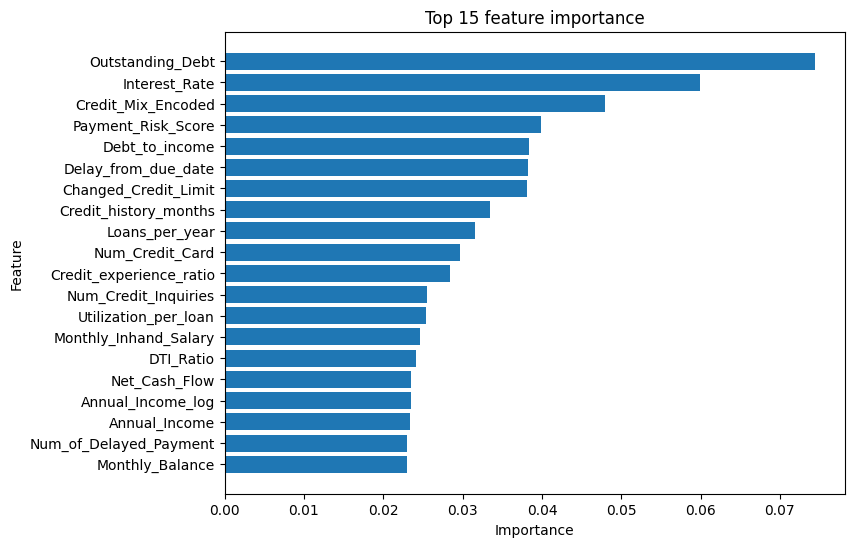

In [240]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'],top_features['Importance'])
plt.gca().invert_yaxis()

plt.title('Top 15 feature importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [241]:
feature_importance.tail(20)

,Feature,Importance
37,Home_Equity_Loan,0.003408
40,Mortgage_Loan,0.003376
48,Occupation_Developer,0.002223
58,Occupation_Scientist,0.002186
53,Occupation_Lawyer,0.002176
59,Occupation_Teacher,0.002138
55,Occupation_Mechanic,0.002130
50,Occupation_Engineer,0.002104
49,Occupation_Doctor,0.002090
61,Occupation________,0.002067


In [242]:
low_importance = feature_importance[
    feature_importance['Importance'] < 0.005
]

low_importance.count()

,0
Feature,27
Importance,27


In [243]:
x_reduced = x.drop(columns = low_importance['Feature'])

In [244]:
x_reduced.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,98770.0,34.403695,9.687134,18.000000,2.700000e+01,34.000000,4.100000e+01,100.000000
Annual_Income,98770.0,51289.436906,40013.247420,7005.930000,1.932871e+04,36945.280000,7.205092e+04,179987.280000
Monthly_Inhand_Salary,98770.0,4173.496444,3192.535127,303.645417,1.618362e+03,3062.030833,5.913403e+03,15204.633333
Num_Bank_Accounts,98770.0,5.556151,3.066062,0.000000,3.000000e+00,6.000000,7.000000e+00,20.000000
Num_Credit_Card,98770.0,5.745277,2.482680,0.000000,4.000000e+00,5.000000,7.000000e+00,15.000000
Interest_Rate,98770.0,14.912747,9.073773,1.000000,8.000000e+00,13.000000,2.000000e+01,34.000000
Num_of_Loan,98770.0,3.519510,2.418669,0.000000,2.000000e+00,3.000000,5.000000e+00,9.000000
Delay_from_due_date,98770.0,21.052698,14.822714,0.000000,1.000000e+01,18.000000,2.800000e+01,67.000000
Num_of_Delayed_Payment,98770.0,13.577797,6.103715,0.000000,9.000000e+00,14.000000,1.800000e+01,30.000000
Changed_Credit_Limit,98770.0,10.380487,6.708027,-6.490000,5.420000e+00,9.550000,1.463750e+01,36.970000


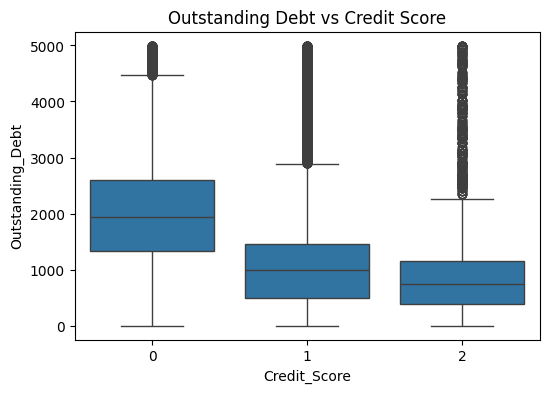

In [245]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x = 'Credit_Score', y = 'Outstanding_Debt', data = dataset)
plt.title('Outstanding Debt vs Credit Score')
plt.show()


In [246]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns
vif_data['VIF'] = [variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])]

vif_data.sort_values(by = 'VIF', ascending = False)

,Feature,VIF
13,Total_EMI_per_month,69503.767939
23,Net_Cash_Flow,68586.514876
17,Annual_Income_log,295.213627
15,Monthly_Balance,180.552957
32,Month_num,105.181483
0,Age,80.664113
16,Credit_history_months,77.203251
26,Credit_experience_ratio,61.898005
12,Credit_Utilization_Ratio,48.806824
2,Monthly_Inhand_Salary,34.926291


In [247]:
drop_col = ['Net_Cash_Flow','Annual_Income_log','Monthly_Balance','Month_num']

x_reduced = x_reduced.drop(columns=drop_col)

In [248]:
vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns
vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])
]

vif_data.sort_values(by='VIF',ascending = False)

,Feature,VIF
15,Credit_history_months,68.437586
0,Age,46.830684
12,Credit_Utilization_Ratio,40.808358
23,Credit_experience_ratio,40.705206
7,Delay_from_due_date,32.178494
19,Payment_Risk_Score,32.175907
2,Monthly_Inhand_Salary,29.493553
1,Annual_Income,27.128672
8,Num_of_Delayed_Payment,20.388263
6,Num_of_Loan,16.628193


In [249]:

x_reduced = x_reduced.drop(columns = 'Credit_experience_ratio'	)

In [250]:
x_reduced.columns

Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly',
       'Credit_history_months', 'DTI_Ratio', 'Loans_per_year',
       'Card_to_account_ratio', 'Payment_Risk_Score', 'Invested_Income_Ratio',
       'Utilization_per_loan', 'Inquiry_per_loan', 'Debt_to_income',
       'Credit_Mix_Encoded', 'Min_Payment_Encoded', 'Payment_Size_Encoded',
       'Spending_Level_Encoded', 'Month_sin', 'Month_cos'],
      dtype='object')

In [251]:
vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns

vif_data['VIF'] = [variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])]

vif_data.sort_values(by='VIF',ascending = False)

,Feature,VIF
12,Credit_Utilization_Ratio,36.304776
7,Delay_from_due_date,31.317826
19,Payment_Risk_Score,31.164040
2,Monthly_Inhand_Salary,29.487345
1,Annual_Income,27.128264
8,Num_of_Delayed_Payment,19.619425
6,Num_of_Loan,16.507291
15,Credit_history_months,13.859559
10,Num_Credit_Inquiries,13.798376
0,Age,12.601258


In [252]:
x_reduced = x_reduced.drop(columns='Annual_Income')

In [253]:
vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns



vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])
]

vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
11,Credit_Utilization_Ratio,36.299325
6,Delay_from_due_date,31.317821
18,Payment_Risk_Score,31.163784
7,Num_of_Delayed_Payment,19.618795
5,Num_of_Loan,16.507157
14,Credit_history_months,13.859557
9,Num_Credit_Inquiries,13.798371
0,Age,12.599669
3,Num_Credit_Card,11.853301
10,Outstanding_Debt,9.219510


In [254]:
x_reduced = x_reduced.drop(columns=['Payment_Risk_Score'])

In [255]:
vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns


vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])]

vif_data.sort_values(by='VIF',ascending=False)

,Feature,VIF
11,Credit_Utilization_Ratio,34.816896
5,Num_of_Loan,16.507031
9,Num_Credit_Inquiries,13.789119
14,Credit_history_months,13.572909
0,Age,12.419788
3,Num_Credit_Card,11.813965
7,Num_of_Delayed_Payment,9.916065
10,Outstanding_Debt,9.101073
2,Num_Bank_Accounts,8.984667
19,Utilization_per_loan,8.954337


In [256]:
x_reduced = x_reduced.drop(columns = 'Loans_per_year')

In [257]:
vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns

vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])
]

vif_data.sort_values(by='VIF',ascending = False)

,Feature,VIF
11,Credit_Utilization_Ratio,34.753214
9,Num_Credit_Inquiries,13.766055
5,Num_of_Loan,12.445988
0,Age,12.314843
3,Num_Credit_Card,11.813592
7,Num_of_Delayed_Payment,9.894441
14,Credit_history_months,9.835166
2,Num_Bank_Accounts,8.976879
10,Outstanding_Debt,8.761731
18,Utilization_per_loan,8.711268


In [258]:
x_reduced = x_reduced.drop(columns = 'Utilization_per_loan')

In [259]:
vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns

vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])
]

vif_data.sort_values(by='VIF',ascending = False)

,Feature,VIF
11,Credit_Utilization_Ratio,26.756018
0,Age,12.280542
9,Num_Credit_Inquiries,11.861332
3,Num_Credit_Card,11.807484
7,Num_of_Delayed_Payment,9.882488
14,Credit_history_months,9.833687
5,Num_of_Loan,9.809861
2,Num_Bank_Accounts,8.966821
10,Outstanding_Debt,8.598258
4,Interest_Rate,7.771926


In [260]:
x_reduced = x_reduced.drop(columns = 'Inquiry_per_loan')

In [261]:
vif_data = pd.DataFrame()

vif_data['Feature']=x_reduced.columns

vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])
]

vif_data.sort_values(by='VIF', ascending=False)

,Feature,VIF
11,Credit_Utilization_Ratio,26.424959
0,Age,12.249597
3,Num_Credit_Card,11.806371
7,Num_of_Delayed_Payment,9.871841
14,Credit_history_months,9.744014
2,Num_Bank_Accounts,8.962660
10,Outstanding_Debt,8.598245
4,Interest_Rate,7.759255
5,Num_of_Loan,5.804331
6,Delay_from_due_date,5.793643


In [262]:
x_reduced = x_reduced.drop(columns='Outstanding_Debt')

vif_data = pd.DataFrame()

vif_data['Feature'] = x_reduced.columns

vif_data['VIF'] = [
    variance_inflation_factor(x_reduced.values,i) for i in range(x_reduced.shape[1])
]

vif_data.sort_values(by='VIF',ascending = False)

,Feature,VIF
10,Credit_Utilization_Ratio,26.423878
0,Age,12.248064
3,Num_Credit_Card,11.765766
7,Num_of_Delayed_Payment,9.828733
13,Credit_history_months,9.420609
2,Num_Bank_Accounts,8.950399
4,Interest_Rate,7.570128
6,Delay_from_due_date,5.658356
5,Num_of_Loan,5.529511
19,Min_Payment_Encoded,5.429814


In [263]:
corr = x_reduced.corr()

corr['Credit_Utilization_Ratio'].sort_values(ascending = False)

,Credit_Utilization_Ratio
Credit_Utilization_Ratio,1.000000
Monthly_Inhand_Salary,0.184602
Spending_Level_Encoded,0.083775
Credit_history_months,0.069922
Payment_Size_Encoded,0.069809
Credit_Mix_Encoded,0.049727
Card_to_account_ratio,0.028433
Age,0.016107
Amount_invested_monthly,0.008186
Total_EMI_per_month,0.001247


In [264]:
x_train = x_reduced
y_train = y

In [265]:
dataset_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')

In [267]:
dataset_test.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [268]:
cat_col_test = dataset_test.select_dtypes(include='object').columns
cat_col_test

Index(['Name', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour'],
      dtype='object')

In [269]:
num_col_test =  dataset_test.select_dtypes(exclude = 'object').columns
num_col_test



Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

In [270]:
dataset_test['Payment_Behaviour'].value_counts()

,count
Payment_Behaviour,
Low_spent_Small_value_payments,14151
High_spent_Medium_value_payments,9689
Low_spent_Medium_value_payments,7363
High_spent_Large_value_payments,7343
High_spent_Small_value_payments,6028
Low_spent_Large_value_payments,5426


In [271]:
q3 = dataset_test['Num_Credit_Inquiries'].quantile([0.75,0.95,0.97,0.99])
q3

,Num_Credit_Inquiries
0.75,10.0
0.95,14.0
0.97,15.0
0.99,16.0


In [272]:
dataset_test['Num_Credit_Inquiries'].describe()

,Num_Credit_Inquiries
count,50000.00000
mean,7.24032
std,3.96097
min,0.00000
25%,4.00000
50%,7.00000
75%,10.00000
max,17.00000


In [273]:
for col in dataset_test.columns:
  if dataset_test[col].isna().sum() > 0 :
    print(col)

In [274]:
set(x_train.columns) - set(dataset_test.columns)

{'Card_to_account_ratio',
 'Credit_Mix_Encoded',
 'Credit_history_months',
 'DTI_Ratio',
 'Debt_to_income',
 'Invested_Income_Ratio',
 'Min_Payment_Encoded',
 'Month_cos',
 'Month_sin',
 'Payment_Size_Encoded',
 'Spending_Level_Encoded'}

In [275]:
set(dataset_test.columns) - set(x_train.columns)

{'Annual_Income',
 'Credit_History_Age',
 'Credit_Mix',
 'Customer_ID',
 'ID',
 'Month',
 'Monthly_Balance',
 'Name',
 'Occupation',
 'Outstanding_Debt',
 'Payment_Behaviour',
 'Payment_of_Min_Amount',
 'SSN',
 'Type_of_Loan'}

In [276]:
dataset_test['Card_to_account_ratio'] = dataset_test['Num_Credit_Card']/(dataset['Num_Bank_Accounts']+1)

In [277]:
credit_mix_map = {'Bad':0,'Unknown':-1,'Good':2,'Standard':1}
dataset_test['Credit_Mix_Encoded'] = dataset_test['Credit_Mix'].map(credit_mix_map)

In [278]:
def convert_to_months(x):
  if pd.isna(x):
    return np.nan


  years = int(re.search(r'(\d+)\s*Years',x).group(1)) if 'Years' in x else 0
  months = int(re.search(r'(\d+)\s*Months',x).group(1)) if 'Months' in x else 0

  return years*12 + months

In [279]:
import re

def convert_to_months(x):
  if pd.isna(x):
    return np.nan
  # Convert to string to handle potential non-string values (e.g., floats) that are not NaN
  s = str(x)
  years = int(re.search(r'(\d+)\s*Years',s).group(1)) if 'Years' in s else 0
  months = int(re.search(r'(\d+)\s*Months',s).group(1)) if 'Months' in s else 0

  return years*12 + months

dataset_test['Credit_history_months'] = dataset_test['Credit_History_Age'].apply(convert_to_months)
dataset_test['Credit_history_months'].dtype

dtype('int64')

In [280]:
dataset_test['Credit_history_months'].isna().sum()

np.int64(0)

In [281]:
dataset_test = dataset_test.drop(columns = ['Credit_History_Age'])

In [282]:
missing_percent = dataset_test['Credit_history_months'].isnull().mean()*100

In [283]:
missing_percent

np.float64(0.0)

In [290]:
dataset_test['DTI_Ratio'] = dataset_test['Total_EMI_per_month']/(dataset_test['Monthly_Inhand_Salary']+1)
dataset_test['Debt_to_income'] = dataset_test['Outstanding_Debt']/(dataset['Annual_Income']+1)

dataset_test['Invested_Income_Ratio'] = dataset_test['Amount_invested_monthly']/(dataset_test['Monthly_Inhand_Salary']+1)


payment_map = {'No':0, 'Yes':2, 'NM': 1}
dataset_test['Min_Payment_Encoded'] = dataset_test['Payment_of_Min_Amount'].map(payment_map)


dataset_test['Month_num']=dataset_test['Month'].map(month_map)

dataset_test['Month_num'].value_counts()

dataset_test['Month_sin'] = np.sin(2*np.pi*dataset_test['Month_num']/12)
dataset_test['Month_cos'] = np.cos(2*np.pi*dataset_test['Month_num']/12)





In [293]:
payment_size_map = {

                'Small':0,
                'Medium':1,
                'Large':2,
                'Unknown':-1
}

dataset_test['Payment_Size_Encoded'] = dataset_test['Payment_Size'].map(payment_size_map)



In [295]:
set(x_train.columns) - set(dataset_test.columns)

set()

In [296]:
X_test = dataset_test[x_train.columns]

In [297]:
print(X_test.shape)

print(x_train.shape)

(50000, 24)
(98770, 24)


In [298]:
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(X_test)

In [299]:
X_test_scaled.shape

(50000, 24)

In [300]:
X_test.isna().sum()

,0
Age,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Num_Credit_Inquiries,0


In [301]:
dataset_test['Month'].value_counts()

,count
Month,
9,12500
10,12500
11,12500
12,12500


In [302]:

dataset_test['Month_num'] = dataset_test['Month']

In [303]:
dataset_test['Month_num']

,Month_num
0,9
1,10
2,11
3,12
4,9
...,...
49995,12
49996,9
49997,10
49998,11


In [304]:
X_test.isna().sum()

,0
Age,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Num_Credit_Inquiries,0


In [ ]:

dataset_test['Month_num'].value_counts()

In [305]:
dataset_test['Month_sin'] = np.sin(2*np.pi*dataset_test['Month_num']/12)
dataset_test['Month_cos'] = np.cos(2*np.pi*dataset_test['Month_num']/12)

In [306]:
dataset_test['Month_cos'].isna().sum()


np.int64(0)

In [307]:
dataset_test.isna().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


In [308]:
X_test.loc[:, 'Card_to_account_ratio'] = X_test['Card_to_account_ratio'].fillna(
    x_train['Card_to_account_ratio'].median()
)

X_test.loc[:, 'Debt_to_income'] = X_test['Debt_to_income'].fillna(
    x_train['Debt_to_income'].median()
)

In [309]:
X_test.columns

Index(['Age', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly',
       'Credit_history_months', 'DTI_Ratio', 'Card_to_account_ratio',
       'Invested_Income_Ratio', 'Debt_to_income', 'Credit_Mix_Encoded',
       'Min_Payment_Encoded', 'Payment_Size_Encoded', 'Spending_Level_Encoded',
       'Month_sin', 'Month_cos'],
      dtype='object')

In [311]:
X_test['Month_sin'] = np.sin(2*np.pi*dataset_test['Month']/12)
X_test['Month_cos'] = np.cos(2*np.pi*dataset_test['Month']/12)

/tmp/ipykernel_787/3519869204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Month_sin'] = np.sin(2*np.pi*dataset_test['Month']/12)
/tmp/ipykernel_787/3519869204.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Month_cos'] = np.cos(2*np.pi*dataset_test['Month']/12)


In [314]:
X_test.isna().sum()

,0
Age,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Num_Credit_Inquiries,0


In [313]:
X_test_scaled = scaler.transform(X_test)

In [315]:
X_test_scaled.shape

(50000, 24)

In [316]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [319]:
y_pred_test = model.predict(X_test_scaled)
y_pred_test[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2])

In [320]:
mapping = {0:'Poor',1:'Good',2:'Standard'}
y_pred_labels = pd.Series(y_pred_test).map(mapping)

In [321]:
final_output = pd.DataFrame({
    'ID' : dataset_test['ID'],
    'Credit_Score_Predicted' : y_pred_labels
})

In [322]:
final_output.head()

,ID,Credit_Score_Predicted
0,5642,Standard
1,5643,Standard
2,5644,Standard
3,5645,Standard
4,5654,Standard


In [323]:
final_output.to_csv('credit_score_predictions.csv',index=False)

In [324]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    n_jobs = -1)

rf_model.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [325]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_rf = rf_model.predict(x_train)

print(classification_report(y_train,y_pred_rf))

print("Accuracy: ", accuracy_score(y_train, y_pred_rf))

              precision    recall  f1-score   support

           0       0.75      0.69      0.72     28643
           1       0.77      0.78      0.77     52556
           2       0.63      0.69      0.66     17571

    accuracy                           0.74     98770
   macro avg       0.72      0.72      0.72     98770
weighted avg       0.74      0.74      0.74     98770

Accuracy:  0.7368127974081199


In [326]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    x_train,
    y_train,
    test_size = 0.2,
    random_state = 42
)

In [328]:
X_train_new.shape, X_val.shape

((79016, 24), (19754, 24))

In [329]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train_new, y_train_new
)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [330]:
y_pred_val = rf_model.predict(X_val)

print(classification_report(y_val,y_pred_val))

print("Validation Accuracy:", accuracy_score(y_val,y_pred_val))

              precision    recall  f1-score   support

           0       0.73      0.67      0.70      5715
           1       0.74      0.76      0.75     10500
           2       0.59      0.64      0.61      3539

    accuracy                           0.71     19754
   macro avg       0.69      0.69      0.69     19754
weighted avg       0.71      0.71      0.71     19754

Validation Accuracy: 0.7114002227396983


In [331]:
rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 15,
    min_samples_leaf = 5,
    random_state = 42,
    n_jobs = -1
)

rf_model.fit(X_train_new, y_train_new
)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [332]:
y_pred_val = rf_model.predict(X_val)

print(classification_report(y_val,y_pred_val))

print("Validation Accuracy:", accuracy_score(y_val,y_pred_val))

              precision    recall  f1-score   support

           0       0.77      0.71      0.74      5715
           1       0.77      0.78      0.78     10500
           2       0.63      0.68      0.66      3539

    accuracy                           0.74     19754
   macro avg       0.72      0.72      0.72     19754
weighted avg       0.74      0.74      0.74     19754

Validation Accuracy: 0.7420775539131316


In [333]:
feature_importance = pd.DataFrame({
    'Feature' : X_train_new.columns,
    'Importance' : rf_model.feature_importances_
}).sort_values(by = 'Importance',ascending = False)

feature_importance.head(20)

,Feature,Importance
4,Interest_Rate,0.131619
18,Credit_Mix_Encoded,0.122572
17,Debt_to_income,0.074969
6,Delay_from_due_date,0.073101
9,Num_Credit_Inquiries,0.065521
8,Changed_Credit_Limit,0.057519
3,Num_Credit_Card,0.055769
13,Credit_history_months,0.051674
2,Num_Bank_Accounts,0.041621
19,Min_Payment_Encoded,0.037856


In [334]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42,
    use_label_encoder = False,
    eval_metric = 'mlogloss'
)

xgb_model.fit(X_train_new, y_train_new)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:02:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [335]:
y_pred_xgb = xgb_model.predict(X_val)

print(classification_report(y_val,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73      5715
           1       0.77      0.78      0.78     10500
           2       0.65      0.68      0.66      3539

    accuracy                           0.74     19754
   macro avg       0.73      0.73      0.72     19754
weighted avg       0.74      0.74      0.74     19754



In [336]:
print('XGBoost Validation Accuracy score:',accuracy_score(y_val,y_pred_xgb))

XGBoost Validation Accuracy score: 0.7438493469677028


In [337]:
xgb_model.fit(x_train,y_train)

y_pred_xgb_test = xgb_model.predict(X_test)

y_pred_xgb_test[:10]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:10:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [338]:
mapping = {0: 'Poor', 1: 'Standard', 2: 'Good'}

y_pred_labels = pd.Series(y_pred_xgb_test).map(mapping)

final_output = pd.DataFrame({
    'ID': dataset_test['ID'],
    'Credit_Score_Predicted': y_pred_labels
})

final_output.head()

,ID,Credit_Score_Predicted
0,5642,Standard
1,5643,Standard
2,5644,Standard
3,5645,Standard
4,5654,Standard
